In [1]:
import wfdb
import os
import pandas as pd

annotation_folder = 'mit-bih-arrhythmia-database-1.0.0'

NORMAL_BEATS = ['N', 'L', 'R', 'e', 'j', '.']
ARRHYTHMIC_BEATS = ['A', 'a', 'J', 'S', 'V', 'E', 'F']

# Collect all files first
files = [f for f in os.listdir(annotation_folder) if f.endswith('.atr') and not f.startswith('._')]

# Map base record names to the "latest" file
record_map = {}
for f in files:
    base = f.replace('.atr', '').replace('-0', '')
    # Always keep the '-0' version if it exists
    if '-0' in f:
        record_map[base] = f
    elif base not in record_map:
        record_map[base] = f

summary = []

for base, ann_file in sorted(record_map.items()):
    record_name = ann_file.replace('.atr', '')  # remove extension for rdann
    try:
        ann = wfdb.rdann(os.path.join(annotation_folder, record_name), 'atr')
    except Exception as e:
        print(f"Skipping {record_name} due to read error: {e}")
        continue

    normal_beats = sum(sym in NORMAL_BEATS for sym in ann.symbol)
    arrhythmic_beats = sum(sym in ARRHYTHMIC_BEATS for sym in ann.symbol)

    # Use base name for display, but data comes from latest file
    summary.append([base, normal_beats, arrhythmic_beats])

df = pd.DataFrame(summary, columns=["Record", "Normal", "Arrhythmic"])

# Show only record 102
print(df[df["Record"]=="116"])


/Users/halders2/.local/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


   Record  Normal  Arrhythmic
15    116    2302         110


In [2]:
# Highlight patients:
normal_thresh = 700
arrhythmic_thresh = 100

# Convert to DataFrame
df = pd.DataFrame(summary, columns=['Record', 'Normal', 'Arrhythmic'])
df.set_index('Record', inplace=True)

# Sort by Normal beats
df_plot = df.sort_values(by='Normal', ascending=False)

# Add a flag column for patients to highlight
df_plot['Highlight'] = ((df_plot['Normal'] >= normal_thresh) &
                        (df_plot['Arrhythmic'] >= arrhythmic_thresh)).astype(int)

# Sort by Highlight first, then Normal
df_plot = df_plot.sort_values(by=['Highlight', 'Normal'], ascending=[False, False])

# Drop highlight column for plotting
df_plot_plot = df_plot.drop(columns=['Highlight'])

# Filter patient records using dynamic thresholds
patients_normal_and_arr = df[(df['Normal'] >= normal_thresh) & (df['Arrhythmic'] >= arrhythmic_thresh)].index.tolist()

print(f"Patient Record IDs with Normal ≥ {normal_thresh:.1f} AND Arrhythmic ≥ {arrhythmic_thresh:.1f}:")
print(patients_normal_and_arr)

num_patients_normal_and_arr = len(patients_normal_and_arr)
print(f"Number of patient records with Normal ≥ {normal_thresh:.1f} AND Arrhythmic ≥ {arrhythmic_thresh:.1f}: {num_patients_normal_and_arr}")


Patient Record IDs with Normal ≥ 700.0 AND Arrhythmic ≥ 100.0:
['106', '116', '118', '119', '200', '201', '203', '207', '208', '209', '210', '213', '214', '215', '221', '222', '223', '228', '233']
Number of patient records with Normal ≥ 700.0 AND Arrhythmic ≥ 100.0: 19


In [3]:
# Filter patients by thresholds
patients_filtered = df[(df['Normal'] >= normal_thresh) & (df['Arrhythmic'] >= arrhythmic_thresh)]

# Sort patients by Normal first, then Arrhythmic (descending order)
patients_sorted = patients_filtered.sort_values(by=['Normal', 'Arrhythmic'], ascending=[False, False])

# Get the patient record IDs in that sorted order
patients_normal_and_arr = patients_sorted.index.tolist()

print(f"Patient Record IDs with Normal ≥ {normal_thresh:.1f} AND Arrhythmic ≥ {arrhythmic_thresh:.1f}:")
print(patients_normal_and_arr)

num_patients_normal_and_arr = len(patients_normal_and_arr)
print(f"Number of patient records with Normal ≥ {normal_thresh:.1f} AND Arrhythmic ≥ {arrhythmic_thresh:.1f}: {num_patients_normal_and_arr}")


Patient Record IDs with Normal ≥ 700.0 AND Arrhythmic ≥ 100.0:
['215', '213', '209', '203', '210', '116', '222', '233', '118', '223', '221', '214', '200', '228', '201', '208', '119', '207', '106']
Number of patient records with Normal ≥ 700.0 AND Arrhythmic ≥ 100.0: 19


/var/folders/rp/3svz678x3dlfx98xp15q82b12rg7gw/T/ipykernel_92649/1823061738.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


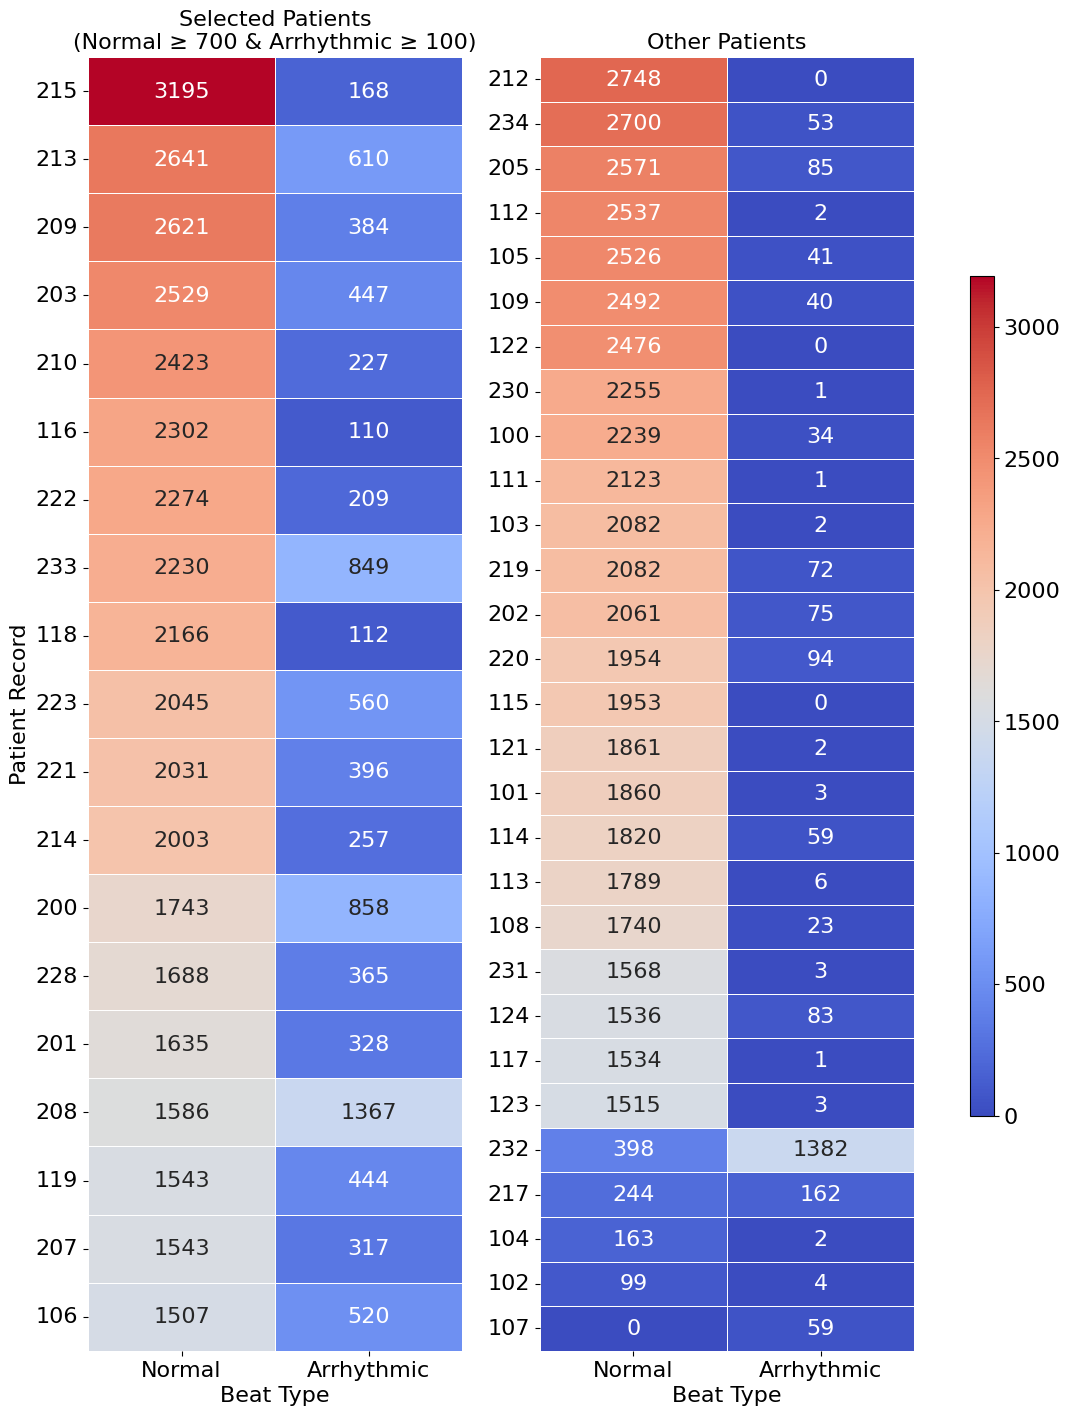

In [4]:
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import seaborn as sns


# Split patients using dynamic thresholds
highlighted = df_plot_plot[(df_plot_plot['Normal'] >= normal_thresh) & 
                           (df_plot_plot['Arrhythmic'] >= arrhythmic_thresh)]
non_highlighted = df_plot_plot[(df_plot_plot['Normal'] < normal_thresh) | 
                               (df_plot_plot['Arrhythmic'] < arrhythmic_thresh)]

# Determine global min and max for color scaling
vmin = df_plot_plot.values.min()
vmax = df_plot_plot.values.max()

# Create figure with gridspec
fig = plt.figure(figsize=(12, max(len(df_plot_plot)*0.35, 6)))
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 0.07], wspace=0.3)

# --- Left: Highlighted patients ---
ax0 = fig.add_subplot(gs[0, 0])
sns.heatmap(
    highlighted, annot=True, fmt='d', cmap='coolwarm', linewidths=0.5,
    cbar=False, ax=ax0, annot_kws={"size": 16},
    yticklabels=highlighted.index,
    vmin=vmin, vmax=vmax  # same color scale
)
ax0.set_title(f"Selected Patients\n(Normal ≥ {normal_thresh} & Arrhythmic ≥ {arrhythmic_thresh})", fontsize=16)
ax0.set_ylabel("Patient Record", fontsize=16)
ax0.set_xlabel("Beat Type", fontsize=16)
ax0.tick_params(axis='x', labelsize=16)
ax0.tick_params(axis='y', labelsize=16, rotation=0)

# --- Right: Non-highlighted patients ---
ax1 = fig.add_subplot(gs[0, 1])
sns.heatmap(
    non_highlighted, annot=True, fmt='d', cmap='coolwarm', linewidths=0.5,
    cbar=False, ax=ax1, annot_kws={"size": 16},
    yticklabels=non_highlighted.index,
    vmin=vmin, vmax=vmax  # same color scale
)
ax1.set_title("Other Patients", fontsize=16)
ax1.set_ylabel("")
ax1.set_xlabel("Beat Type", fontsize=16)
ax1.tick_params(axis='x', labelsize=16)
ax1.tick_params(axis='y', labelsize=16, rotation=0)

# --- Shared colorbar ---
cbar_ax = fig.add_subplot(gs[0, 2])
cbar_ax.set_position([0.86, 0.25, 0.02, 0.5])  # [left, bottom, width, height]

# Create ScalarMappable
sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=plt.cm.colors.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])

# Add colorbar
cbar = fig.colorbar(sm, cax=cbar_ax)

# Increase tick label size
cbar.ax.tick_params(labelsize=16)

# Save the figure as a PNG with 300 dpi
fig.savefig("MITBIH_beat_counts.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()
